# 2026 NCAA Tournament — Bracket EDA

A quick look at which teams should do well based on KenPom efficiency metrics.

**Key metric: AdjEM (Adjusted Efficiency Margin)**  
Points scored minus points allowed per 100 possessions, adjusted for opponent strength. The single best predictor of tournament success.

- **AdjOE** — Adjusted Offensive Efficiency (points scored per 100 possessions vs avg defense)
- **AdjDE** — Adjusted Defensive Efficiency (points allowed per 100 possessions vs avg offense) — *lower is better*
- **AdjEM** = AdjOE − AdjDE — Net rating; higher = better

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

## 1. Load Data

In [2]:
# 2026 KenPom efficiency data (all D1 teams)
kenpom = pd.read_csv('../data/processed/kenpom_2026_clean.csv')
print(f"Total D1 teams: {len(kenpom)}")
kenpom.head()

Total D1 teams: 365


,team,adj_off_eff,adj_def_eff,adj_tempo,adj_em,efficiency_differential
0,Abilene Christian,102.1810,107.448,66.9733,-5.26775,-5.2670
1,Air Force,96.5754,116.147,65.9718,-19.57140,-19.5716
2,Akron,121.0080,107.936,70.6866,13.07190,13.0720
3,Alabama,129.5330,102.943,73.0985,26.59060,26.5900
4,Alabama A&M,103.8490,116.382,65.2286,-12.53300,-12.5330


In [3]:
# 2026 tournament seeds (from bracket)
SEEDS_2026 = {
    # 1 seeds
    'Duke': 1, 'Arizona': 1, 'Michigan': 1, 'Florida': 1,
    # 2 seeds
    'Houston': 2, 'UConn': 2, 'Iowa St.': 2, 'Purdue': 2,
    # 3 seeds
    'Michigan St.': 3, 'Illinois': 3, 'Gonzaga': 3, 'Virginia': 3,
    # 4 seeds
    'Nebraska': 4, 'Alabama': 4, 'Kansas': 4, 'Arkansas': 4,
    # 5 seeds
    'Vanderbilt': 5, "St. John's": 5, 'Texas Tech': 5, 'Wisconsin': 5,
    # 6 seeds
    'Tennessee': 6, 'North Carolina': 6, 'Louisville': 6, 'BYU': 6,
    # 7 seeds
    'Kentucky': 7, "Saint Mary's": 7, 'Miami': 7, 'UCLA': 7,
    # 8 seeds
    'Clemson': 8, 'Villanova': 8, 'Ohio St.': 8, 'Georgia': 8,
    # 9 seeds
    'Utah St.': 9, 'TCU': 9, 'Saint Louis': 9, 'Iowa': 9,
    # 10 seeds
    'Santa Clara': 10, 'UCF': 10, 'Missouri': 10, 'Texas A&M': 10,
    # 11 seeds (First Four)
    'NC State': 11, 'Texas': 11, 'SMU': 11, 'Miami OH': 11, 'VCU': 11, 'South Florida': 11,
    # 12 seeds
    'McNeese': 12, 'Akron': 12, 'Northern Iowa': 12, 'High Point': 12,
    # 13 seeds
    'Cal Baptist': 13, 'Hofstra': 13, 'Troy': 13, 'Hawaii': 13,
    # 14 seeds
    'North Dakota St.': 14, 'Penn': 14, 'Wright St.': 14, 'Kennesaw St.': 14,
    # 15 seeds
    'Tennessee St.': 15, 'Idaho': 15, 'Furman': 15, 'Queens': 15,
    # 16 seeds (First Four)
    'Siena': 16, 'LIU': 16, 'Howard': 16, 'UMBC': 16, 'Lehigh': 16, 'Prairie View': 16,
}

# Normalize team names for the merge (KenPom uses slightly different names)
NAME_MAP = {
    'Iowa St.': 'Iowa St.',
    'Michigan St.': 'Michigan St.',
    "St. John's": "St. John's (NY)",
    "Saint Mary's": "Saint Mary's (CA)",
    'Miami': 'Miami FL',
    'Miami OH': 'Miami OH',
    'North Dakota St.': 'N. Dakota St.',
    'Kennesaw St.': 'Kennesaw St.',
    'Tennessee St.': 'Tennessee St.',
    'Cal Baptist': 'California Baptist',
    'Prairie View': 'Prairie View A&M',
    'South Florida': 'South Florida',
    'Wright St.': 'Wright St.',
    'Northern Iowa': 'Northern Iowa',
}

seed_df = pd.DataFrame([
    {'team_seed_name': k, 'seed': v, 'team': NAME_MAP.get(k, k)}
    for k, v in SEEDS_2026.items()
])

# Merge seeds onto KenPom data
bracket = kenpom.merge(seed_df[['team', 'seed']], on='team', how='inner')
print(f"Tournament teams matched: {len(bracket)} / 68")
bracket.sort_values('seed').head(12)

Tournament teams matched: 63 / 68


,team,adj_off_eff,adj_def_eff,adj_tempo,adj_em,efficiency_differential,seed
2,Arizona,126.818,89.6871,70.0650,37.1308,37.1309,1
7,Florida,125.721,90.7363,70.7016,34.9852,34.9847,1
6,Duke,127.694,88.0769,65.3911,39.6167,39.6171,1
29,Michigan,128.367,88.9572,71.4061,39.4097,39.4098,1
19,Iowa St.,123.798,93.5448,66.5518,30.2534,30.2532,2
14,Houston,125.141,92.4653,63.1996,32.6758,32.6757,2
39,Purdue,129.735,98.5365,65.1459,31.1988,31.1985,2
10,Gonzaga,122.296,94.0225,69.0142,28.2736,28.2735,3
17,Illinois,132.247,99.1410,65.2451,33.1055,33.1060,3
30,Michigan St.,121.374,92.2673,65.6188,29.1066,29.1067,3


## 2. Top Teams by AdjEM (Best Overall Rating)

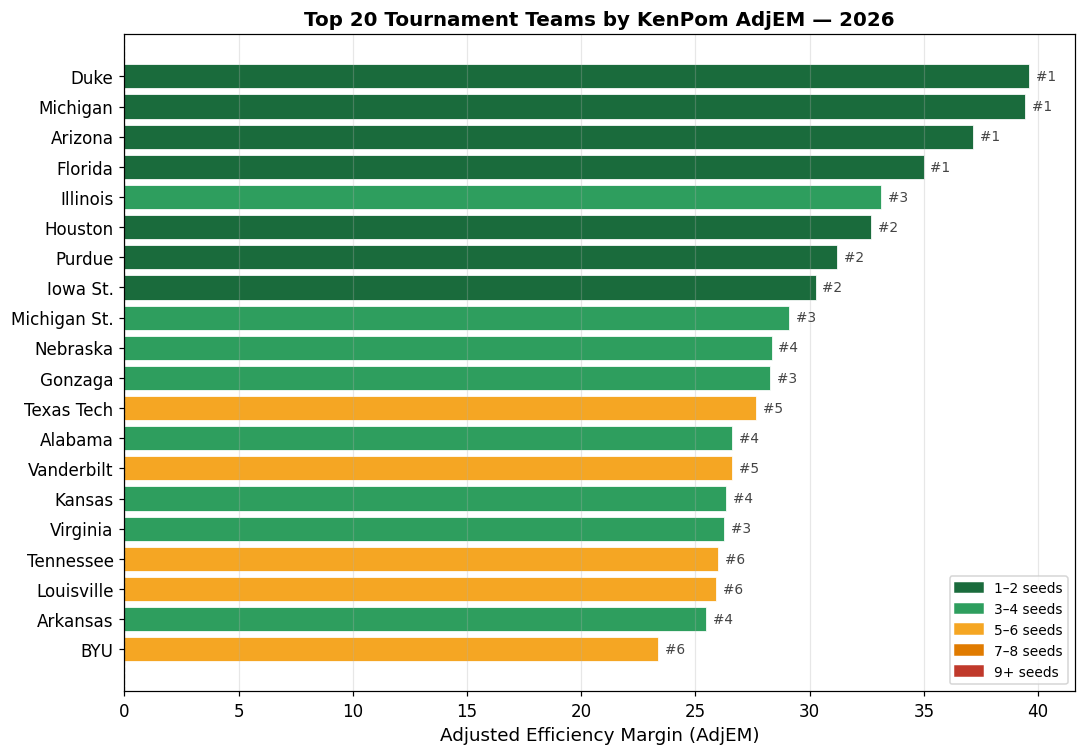

In [4]:
top20 = bracket.sort_values('adj_em', ascending=False).head(20).reset_index(drop=True)

# Color bars by seed group
def seed_color(seed):
    if seed <= 2:   return '#1a6b3c'   # dark green
    if seed <= 4:   return '#2e9e5e'   # medium green
    if seed <= 6:   return '#f5a623'   # orange
    if seed <= 8:   return '#e07b00'   # dark orange
    return '#c0392b'                   # red (double-digit seed)

colors = [seed_color(s) for s in top20['seed']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['team'][::-1], top20['adj_em'][::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

# Annotate with seed
for i, (_, row) in enumerate(top20[::-1].iterrows()):
    ax.text(row['adj_em'] + 0.3, i, f"#{int(row['seed'])}", va='center', fontsize=9, color='#444')

ax.set_xlabel('Adjusted Efficiency Margin (AdjEM)', fontsize=12)
ax.set_title('Top 20 Tournament Teams by KenPom AdjEM — 2026', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

legend_patches = [
    mpatches.Patch(color='#1a6b3c', label='1–2 seeds'),
    mpatches.Patch(color='#2e9e5e', label='3–4 seeds'),
    mpatches.Patch(color='#f5a623', label='5–6 seeds'),
    mpatches.Patch(color='#e07b00', label='7–8 seeds'),
    mpatches.Patch(color='#c0392b', label='9+ seeds'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Offensive vs. Defensive Efficiency — Team Quadrant Chart

- **Top-left**: Elite defense, weak offense  
- **Top-right**: Elite on both ends — Final Four contenders  
- **Bottom-right**: Elite offense, weak defense  
- **Bottom-left**: Below average on both ends

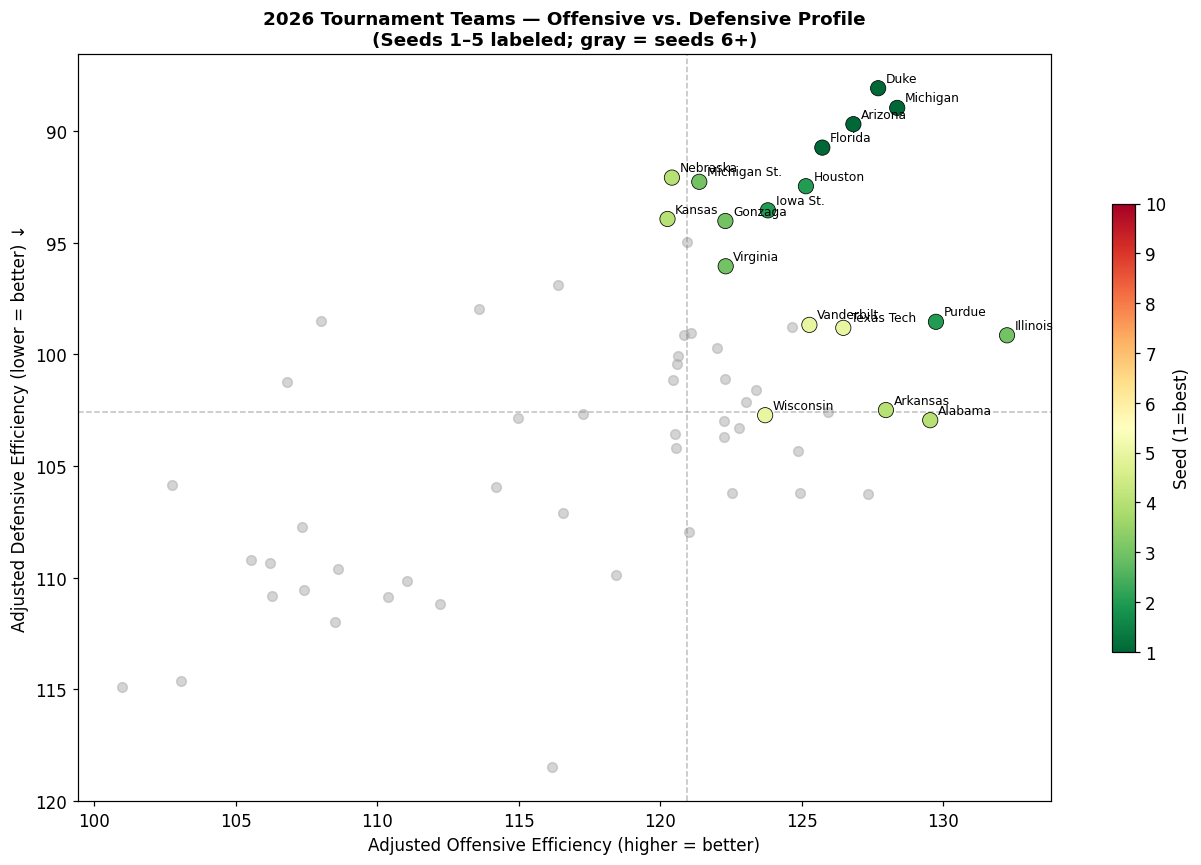

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

# Only label top seeds for readability
label_seeds = bracket[bracket['seed'] <= 5]
other = bracket[bracket['seed'] > 5]

ax.scatter(other['adj_off_eff'], other['adj_def_eff'],
           c='#aaa', alpha=0.5, s=40, zorder=2)
scatter = ax.scatter(label_seeds['adj_off_eff'], label_seeds['adj_def_eff'],
                     c=label_seeds['seed'], cmap='RdYlGn_r', vmin=1, vmax=10,
                     s=100, edgecolors='black', linewidth=0.5, zorder=3)

for _, row in label_seeds.iterrows():
    ax.annotate(row['team'], (row['adj_off_eff'], row['adj_def_eff']),
                textcoords='offset points', xytext=(5, 4), fontsize=8)

# Median lines
med_off = bracket['adj_off_eff'].median()
med_def = bracket['adj_def_eff'].median()
ax.axvline(med_off, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_def, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Note: lower AdjDE = better defense, so invert y-axis
ax.invert_yaxis()

ax.set_xlabel('Adjusted Offensive Efficiency (higher = better)', fontsize=11)
ax.set_ylabel('Adjusted Defensive Efficiency (lower = better) ↓', fontsize=11)
ax.set_title('2026 Tournament Teams — Offensive vs. Defensive Profile\n(Seeds 1–5 labeled; gray = seeds 6+)', fontsize=12, fontweight='bold')

plt.colorbar(scatter, ax=ax, label='Seed (1=best)', shrink=0.6)
plt.tight_layout()
plt.show()

## 4. Seed vs. AdjEM — How Well Do Seeds Match the Metrics?

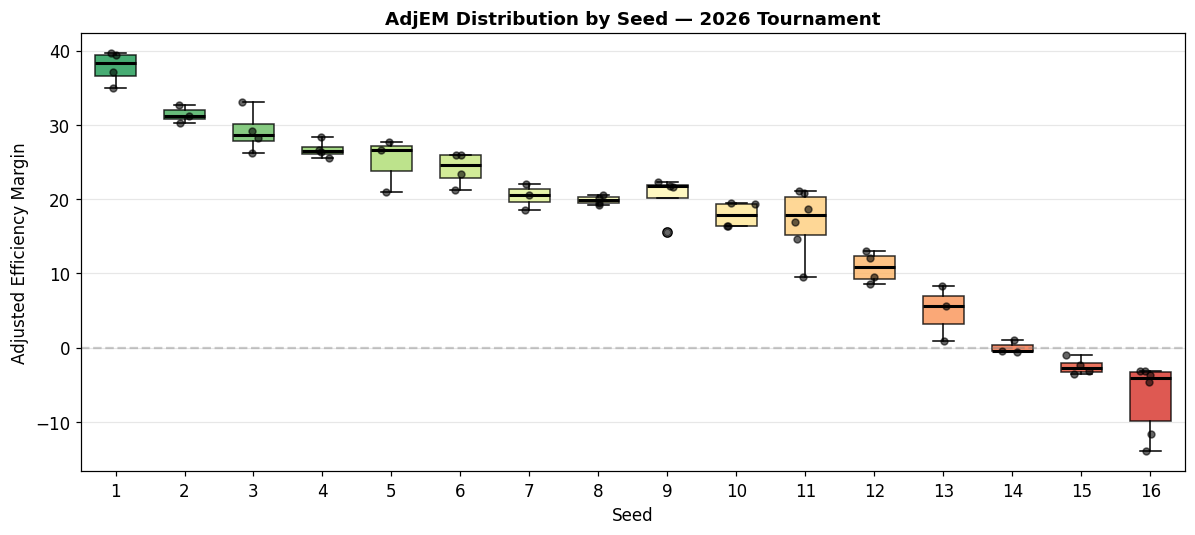

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

# Box plot of AdjEM by seed
seed_groups = [bracket[bracket['seed'] == s]['adj_em'].values for s in range(1, 17)]
bp = ax.boxplot(seed_groups, positions=range(1, 17), patch_artist=True,
                widths=0.6, medianprops=dict(color='black', linewidth=2))

# Color by seed
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 16))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Overlay individual team points
for seed in range(1, 17):
    ys = bracket[bracket['seed'] == seed]['adj_em'].values
    xs = np.random.normal(seed, 0.1, size=len(ys))
    ax.scatter(xs, ys, color='black', s=20, alpha=0.6, zorder=5)

ax.set_xlabel('Seed', fontsize=11)
ax.set_ylabel('Adjusted Efficiency Margin', fontsize=11)
ax.set_title('AdjEM Distribution by Seed — 2026 Tournament', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 17))
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Potential Overseeds & Underseeds

Teams whose KenPom AdjEM ranking doesn't match their seed. These are the most interesting upset candidates.

In [7]:
# Rank teams by AdjEM (1 = best)
bracket = bracket.copy()
bracket['adj_em_rank'] = bracket['adj_em'].rank(ascending=False).astype(int)

# Expected rank based purely on seed (seed 1 → expected rank ~2, seed 16 → ~60)
# Simple heuristic: seed * 4 approximates where they "should" rank among 68 teams
bracket['expected_rank'] = bracket['seed'] * 4
bracket['rank_delta'] = bracket['expected_rank'] - bracket['adj_em_rank']
# Positive delta = team is BETTER than seed suggests (underseed)
# Negative delta = team is WORSE than seed suggests (overseed)

print("=== UNDERSEEDED (Better than seed suggests — upset potential ON them) ===")
underseeded = bracket.nlargest(8, 'rank_delta')[['team', 'seed', 'adj_em', 'adj_em_rank', 'rank_delta']]
underseeded.columns = ['Team', 'Seed', 'AdjEM', 'KenPom Rank', 'Delta (better →)']
print(underseeded.to_string(index=False))

print("\n=== OVERSEEDED (Weaker than seed suggests — upset risk) ===")
overseeded = bracket.nsmallest(8, 'rank_delta')[['team', 'seed', 'adj_em', 'adj_em_rank', 'rank_delta']]
overseeded.columns = ['Team', 'Seed', 'AdjEM', 'KenPom Rank', 'Delta (worse →)']
print(overseeded.to_string(index=False))

=== UNDERSEEDED (Better than seed suggests — upset potential ON them) ===
       Team  Seed    AdjEM  KenPom Rank  Delta (better →)
      Texas    11 21.06790           26                18
   NC State    11 20.88510           28                16
       Iowa     9 22.27550           21                15
   Utah St.     9 21.82050           23                13
Saint Louis     9 21.68400           24                12
      Siena    16 -3.13066           56                 8
        SMU    11 18.71600           36                 8
 Texas Tech     5 27.65490           12                 8

=== OVERSEEDED (Weaker than seed suggests — upset risk) ===
     Team  Seed    AdjEM  KenPom Rank  Delta (worse →)
     UCLA     7 18.54700           37               -9
Wisconsin     5 20.98200           27               -7
      TCU     9 15.63180           41               -5
 Virginia     3 26.25590           16               -4
 Arkansas     4 25.47990           19               -3
 Ohio St.    

## 6. Offensive & Defensive Breakdown — Seeds 1–4

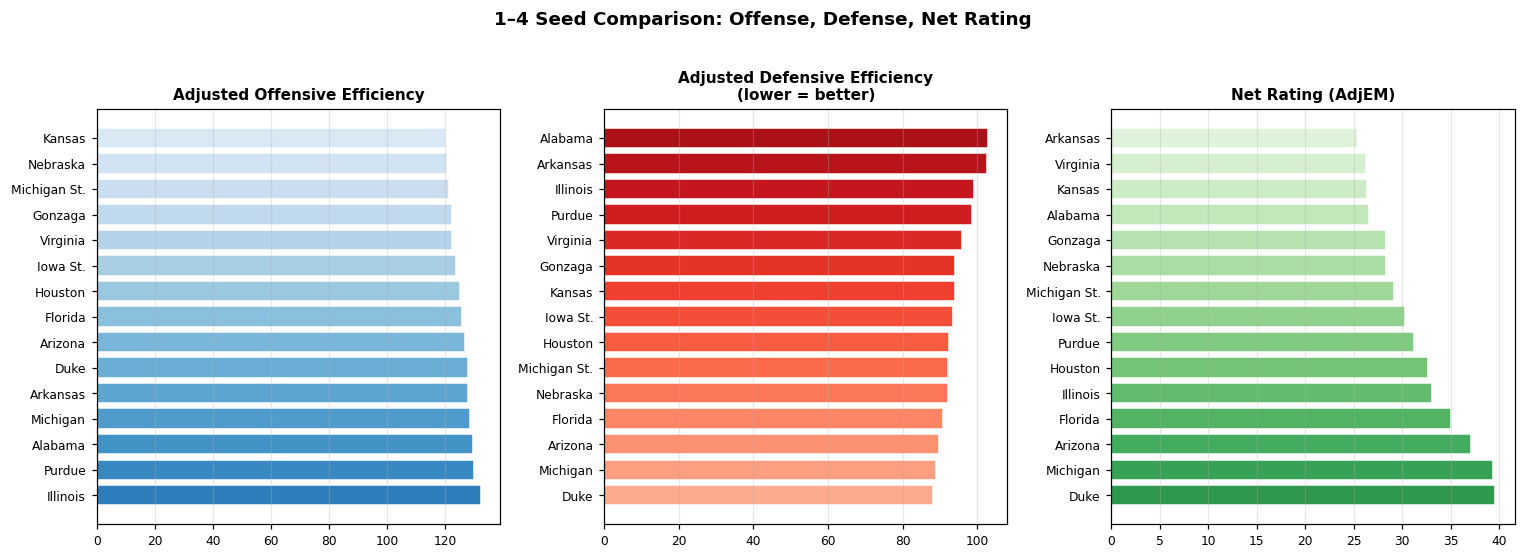

In [8]:
top_seeds = bracket[bracket['seed'] <= 4].sort_values('adj_em', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('adj_off_eff', 'Adjusted Offensive Efficiency', 'Blues_r', False),
    ('adj_def_eff', 'Adjusted Defensive Efficiency\n(lower = better)', 'Reds', True),
    ('adj_em',      'Net Rating (AdjEM)',             'Greens_r', False),
]

for ax, (col, title, cmap, invert) in zip(axes, metrics):
    data = top_seeds.sort_values(col, ascending=invert)
    colors_bar = plt.get_cmap(cmap)(np.linspace(0.3, 0.85, len(data)))
    ax.barh(data['team'], data[col], color=colors_bar, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(labelsize=8)

fig.suptitle('1–4 Seed Comparison: Offense, Defense, Net Rating', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary Table — All Tournament Teams

In [9]:
summary = bracket[['team', 'seed', 'adj_em', 'adj_off_eff', 'adj_def_eff', 'adj_tempo', 'adj_em_rank']].copy()
summary.columns = ['Team', 'Seed', 'AdjEM', 'Adj Off', 'Adj Def', 'Tempo', 'KenPom Rank']
summary = summary.sort_values('AdjEM', ascending=False).reset_index(drop=True)
summary.index += 1

# Style
styled = summary.style \
    .background_gradient(subset=['AdjEM'], cmap='RdYlGn') \
    .background_gradient(subset=['Adj Off'], cmap='Blues') \
    .background_gradient(subset=['Adj Def'], cmap='Reds_r') \
    .format({'AdjEM': '{:.1f}', 'Adj Off': '{:.1f}', 'Adj Def': '{:.1f}', 'Tempo': '{:.1f}'}) \
    .set_caption('2026 Tournament Field — Sorted by AdjEM')

styled

,Team,Seed,AdjEM,Adj Off,Adj Def,Tempo,KenPom Rank
1,Duke,1,39.6,127.7,88.1,65.4,1
2,Michigan,1,39.4,128.4,89.0,71.4,2
3,Arizona,1,37.1,126.8,89.7,70.1,3
4,Florida,1,35.0,125.7,90.7,70.7,4
5,Illinois,3,33.1,132.2,99.1,65.2,5
6,Houston,2,32.7,125.1,92.5,63.2,6
7,Purdue,2,31.2,129.7,98.5,65.1,7
8,Iowa St.,2,30.3,123.8,93.5,66.6,8
9,Michigan St.,3,29.1,121.4,92.3,65.6,9
10,Nebraska,4,28.3,120.4,92.1,66.7,10
